In [2]:
import json
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/home/sgaviria/MalariaProject/')

from src import *

In [14]:
times = np.arange(0, 5.2, 0.2)

In [15]:
times

array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4,
       2.6, 2.8, 3. , 3.2, 3.4, 3.6, 3.8, 4. , 4.2, 4.4, 4.6, 4.8, 5. ])

In [24]:
L_isot = LatticeSOS_v4(size=(80, 80), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_isot.initialize(mode="random", max_height=1, n_seeds=500)

params = KMCParams_v4(
K0_plus= 1.1671806264584635, #0.211,#
K_inc_plus=0.5069325183371898,
E_pb_over_kT_x=0.76085943,
E_pb_over_kT_y=2.19936039,
phi_over_kT= 1.4792478012079329, #3.76, #1.4792478012079329, #
delta_x=0.6,
delta_y=1.7789686274068774,
V=0.9943756704678864,
C_eq=6.66285823642452,
fixed_sigma=0.38,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc = KMC_BKL_v4(
    lattice=L_isot,
    params=params,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=200,
    #n_seeds=100,
    constant_concentration=True,  # batch dinámico
)

In [25]:
snaps, stats = kmc.run(t_end=times[-1], snapshot_times=times)

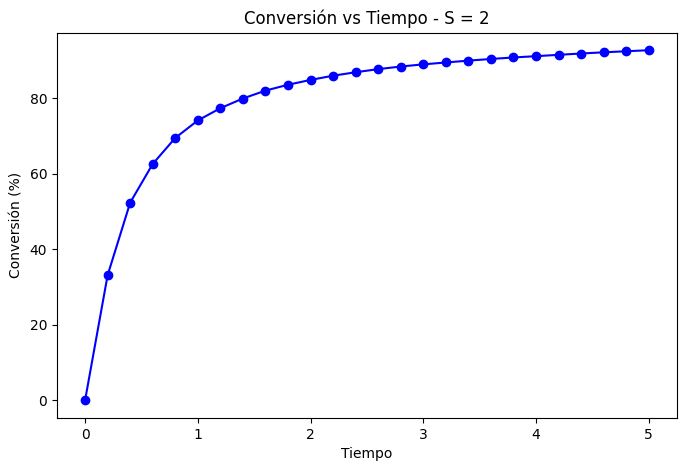

In [26]:
plots = Plotter(kmc)
#plots1 = Plotter(kmc1)
#plots2 = Plotter(kmc2)

plots.plot_conversion(snaps, title=f"Conversión vs Tiempo - S = 2")
#plt.plot(data_txt["Tiempo"], data_txt["Porcentaje"], label="Beta-hematina", marker="s")
#plots1.plot_conversion(snaps1, title=r"Conversión vs Tiempo - S = 2 - $ \phi = E_{pb}/2$")
#plots2.plot_conversion(snaps2, title=r"Conversión vs Tiempo - S = 2 - $ \phi = 0.35*E_{pb}$")
#plots2.crystal_growth_gif(snaps2, save_path=fr"c:\Users\sebas\MalariaProject\results\crystal_growth_S2_1.gif", title_prefix = f"Crystal Growth - S=2")
    

🧩 Snapshot seleccionado: t=5.000


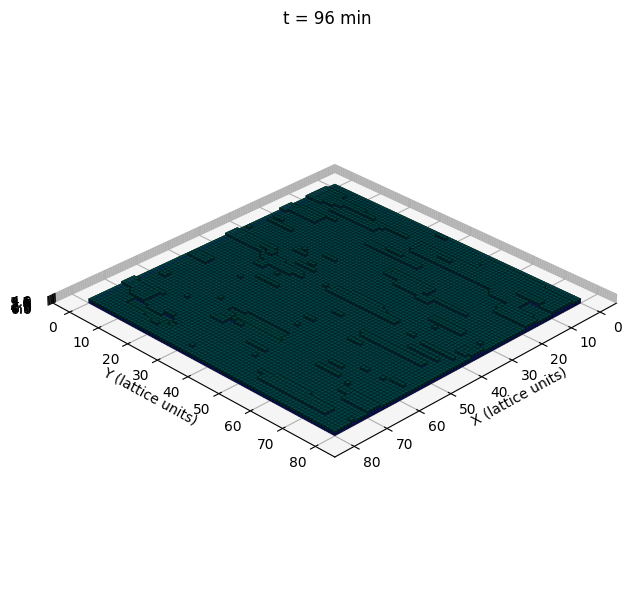

In [33]:
plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps,
    t_snapshot=times[-1],
    title=f"t = {times[-1]*60:.0f} min"
)

In [ ]:
# =========================================================
# CONFIGURACIÓN
# =========================================================
#RUN_DIR = Path("/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_2_seed_123")

dir = [Path("/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_1_seed_123"),
       Path("/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_2_seed_123"),
       Path("/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_3_seed_123"),
       Path("/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_4_seed_123"),
       Path("/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_5_seed_123"),
       Path("/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_6_seed_123")]
# Cambia RUN_DIR por la carpeta de la corrida que quieras cargar

In [8]:
# =========================================================
# FUNCIONES AUXILIARES
# =========================================================
def load_pickle(path: Path):
    with open(path, "rb") as f:
        return pickle.load(f)

def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def reconstruct_kmc_from_metadata(meta: dict):
    """
    Reconstruye un objeto KMC_BKL_v4 equivalente al usado en la corrida,
    sin ejecutar nuevamente kmc.run().
    """
    size = tuple(meta["size"])
    n_seeds = meta["n_seeds"]
    time_scale = meta["time_scale"]
    fixed_sigma = meta["fixed_sigma"]
    rng_seed = meta["rng_seed"]
    lattice_seed = meta["lattice_seed"]

    params_meta = meta["params"]

    Lat = LatticeSOS_v4(size=size, seed=lattice_seed)
    Lat.initialize(mode="flat", max_height=1, n_seeds=n_seeds)

    params = KMCParams_v4(
        K0_plus=params_meta["K0_plus"],
        K_inc_plus=params_meta["K_inc_plus"],
        E_pb_over_kT_x=params_meta["E_pb_over_kT_x"],
        E_pb_over_kT_y=params_meta["E_pb_over_kT_y"],
        phi_over_kT=params_meta["phi_over_kT"],
        delta_x=params_meta["delta_x"],
        delta_y=params_meta["delta_y"],
        V=params_meta["V"],
        C_eq=params_meta["C_eq"],
        fixed_sigma=fixed_sigma,
        S_floor=params_meta["S_floor"],
        S_ceil=params_meta["S_ceil"],
    )

    kmc_otros = KMC_BKL_v4(
        lattice=Lat,
        params=params,
        N_bulk0=meta.get("N_bulk0", 2000),
        rng_seed=rng_seed,
        time_scale=time_scale,
        n_seeds=n_seeds,
        constant_concentration=True,
    )

    return kmc_otros

Corrida cargada correctamente:
  run_id      = size_80x80_sigma_1_seed_123
  size        = [80, 80]
  fixed_sigma = 1.0
  n_seeds     = 500
  time_scale  = 80.0
🧩 Snapshot seleccionado: t=29.000


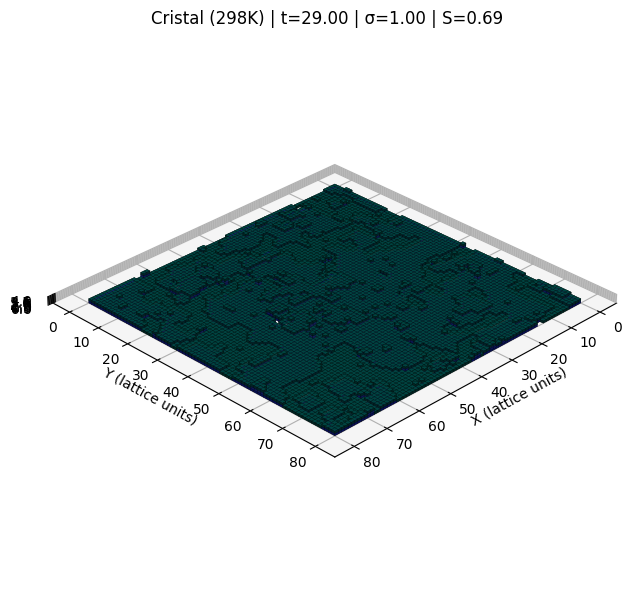

💾 GIF guardado en: crystal_growth_size_80x80_sigma_1_seed_123.gif
Corrida cargada correctamente:
  run_id      = size_80x80_sigma_2_seed_123
  size        = [80, 80]
  fixed_sigma = 2.0
  n_seeds     = 500
  time_scale  = 80.0
🧩 Snapshot seleccionado: t=29.000


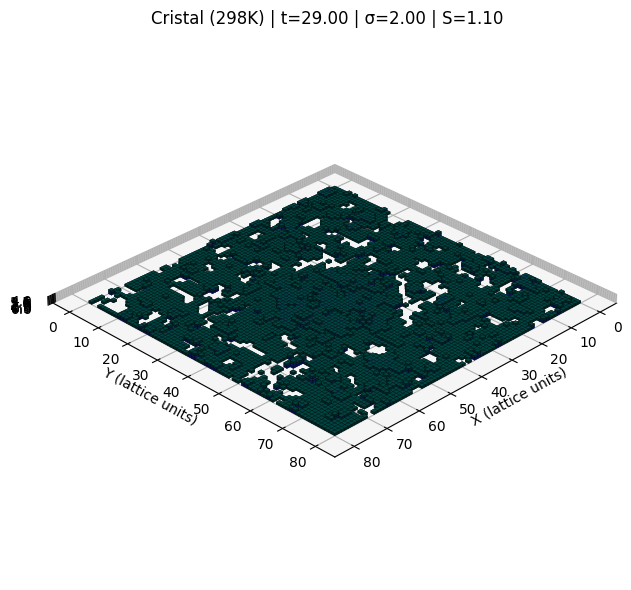

💾 GIF guardado en: crystal_growth_size_80x80_sigma_2_seed_123.gif
Corrida cargada correctamente:
  run_id      = size_80x80_sigma_3_seed_123
  size        = [80, 80]
  fixed_sigma = 3.0
  n_seeds     = 500
  time_scale  = 80.0
🧩 Snapshot seleccionado: t=29.000


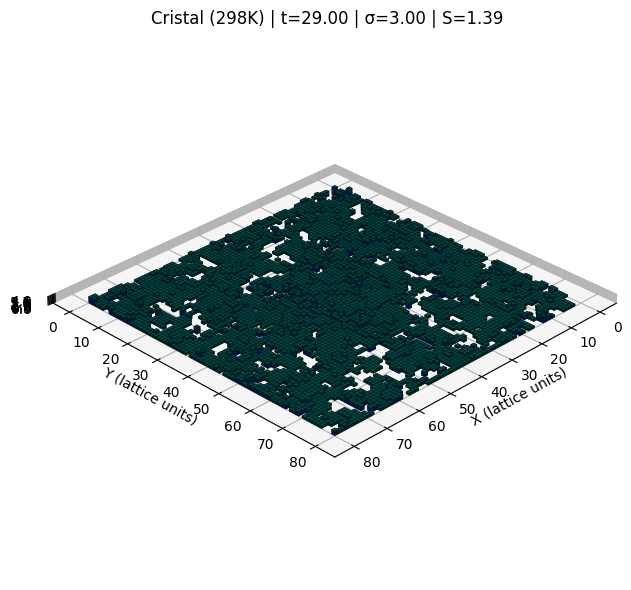

💾 GIF guardado en: crystal_growth_size_80x80_sigma_3_seed_123.gif
Corrida cargada correctamente:
  run_id      = size_80x80_sigma_4_seed_123
  size        = [80, 80]
  fixed_sigma = 4.0
  n_seeds     = 500
  time_scale  = 80.0
🧩 Snapshot seleccionado: t=29.000


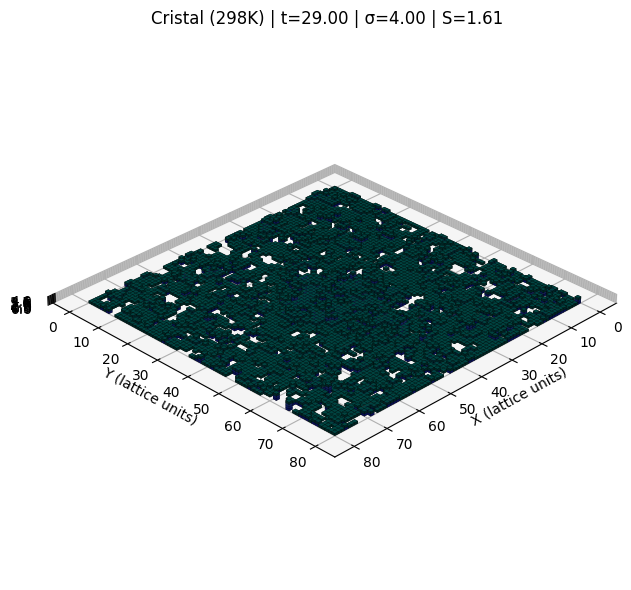

💾 GIF guardado en: crystal_growth_size_80x80_sigma_4_seed_123.gif
Corrida cargada correctamente:
  run_id      = size_80x80_sigma_5_seed_123
  size        = [80, 80]
  fixed_sigma = 5.0
  n_seeds     = 500
  time_scale  = 80.0
🧩 Snapshot seleccionado: t=29.000


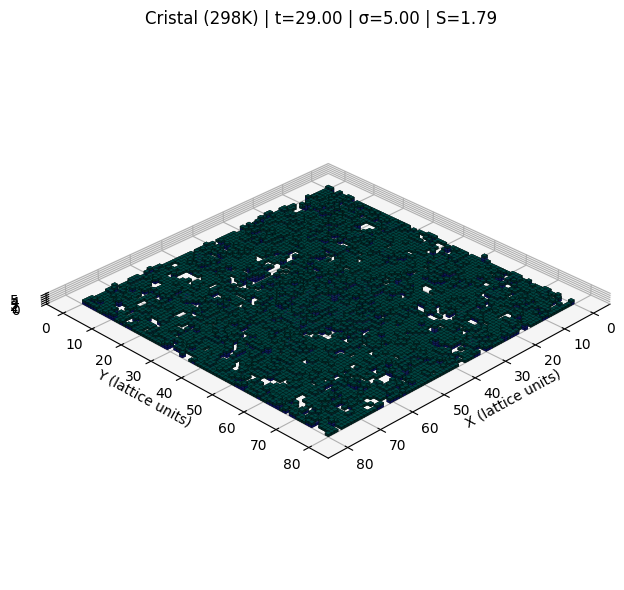

💾 GIF guardado en: crystal_growth_size_80x80_sigma_5_seed_123.gif
Corrida cargada correctamente:
  run_id      = size_80x80_sigma_6_seed_123
  size        = [80, 80]
  fixed_sigma = 6.0
  n_seeds     = 500
  time_scale  = 80.0
🧩 Snapshot seleccionado: t=29.000


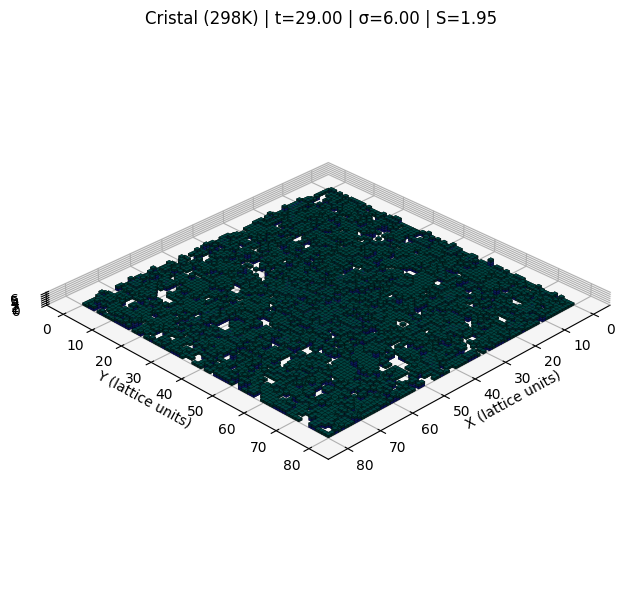

💾 GIF guardado en: crystal_growth_size_80x80_sigma_6_seed_123.gif


In [13]:
# =========================================================
# CARGA DE DATOS
# =========================================================

for RUN_DIR in dir:

    metadata_path = RUN_DIR / "metadata.json"
    snaps_path = RUN_DIR / "snaps.pkl"
    stats_path = RUN_DIR / "stats.pkl"

    if not metadata_path.exists():
        raise FileNotFoundError(f"No existe metadata.json en: {metadata_path}")
    if not snaps_path.exists():
        raise FileNotFoundError(f"No existe snaps.pkl en: {snaps_path}")
    if not stats_path.exists():
        raise FileNotFoundError(f"No existe stats.pkl en: {stats_path}")

    meta_ = load_json(metadata_path)
    snaps_ = load_pickle(snaps_path)
    stats_ = load_pickle(stats_path)

    times = np.array(meta_["times"], dtype=float)

    # =========================================================
    # RECONSTRUCCIÓN DEL OBJETO KMC
    # =========================================================
    kmc_ = reconstruct_kmc_from_metadata(meta_)

    print("Corrida cargada correctamente:")
    print(f"  run_id      = {meta_.get('run_id', 'N/A')}")
    print(f"  size        = {meta_['size']}")
    print(f"  fixed_sigma = {meta_['fixed_sigma']}")
    print(f"  n_seeds     = {meta_['n_seeds']}")
    print(f"  time_scale  = {meta_['time_scale']}")

    # =========================================================
    # USO CON Plotter_v2
    # =========================================================
    plotter = Plotter_v2(kmc_)
    plotter.plot_crystal_3d(
        mode="voxel",
        snapshots=snaps_,
        t_snapshot=times[len(times)-1],
    )

    plotter.crystal_growth_gif(
    snapshots=snaps_,
    save_path=f"crystal_growth_{meta_.get('run_id', 'N/A')}.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento isotrópico 3D",
    every_n=1,
    )

Corrida cargada correctamente:
  run_id      = size_80x80_sigma_2_seed_123
  size        = [80, 80]
  fixed_sigma = 2.0
  n_seeds     = 500
  time_scale  = 80.0
🧩 Snapshot seleccionado: t=29.000


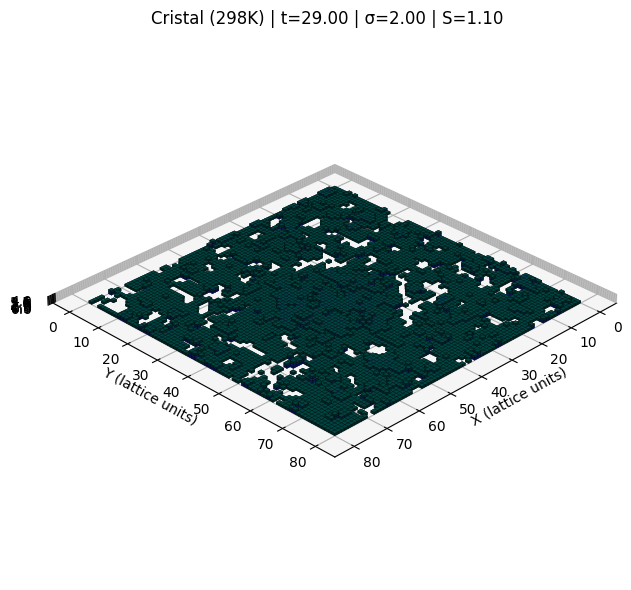

In [ ]:
# =========================================================
# RECONSTRUCCIÓN DEL OBJETO KMC
# =========================================================
kmc_ = reconstruct_kmc_from_metadata(meta_)

print("Corrida cargada correctamente:")
print(f"  run_id      = {meta_.get('run_id', 'N/A')}")
print(f"  size        = {meta_['size']}")
print(f"  fixed_sigma = {meta_['fixed_sigma']}")
print(f"  n_seeds     = {meta_['n_seeds']}")
print(f"  time_scale  = {meta_['time_scale']}")

# =========================================================
# USO CON Plotter_v2
# =========================================================
plotter = Plotter_v2(kmc_)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_,
    t_snapshot=times[len(times)-1],
)